
# Linux Assignment Questions






### Q1. What is Linux?

Linux is based on the **UNIX operating system**, which was first developed in the 1970s at AT&T Bell Labs.  
It is a **free and open-source, multiuser, multitasking OS** that allows its source code to be inspected, modified, and shared by anyone.  
This openness promotes **global collaboration and innovation**.  

Linux provides **efficient performance, portability, and strong security**, making it suitable for servers, desktops, mobile devices, and supercomputers.  
It combines the **kernel, file systems, system utilities, user interfaces, and applications** to form a complete computing environment.  

To create a fully functional system, Linux is bundled with software packages and tools, which together are called **Linux distributions (distros)**, such as Ubuntu, Debian, and Fedora.


### Q2. What is the difference between Hard Link & Soft Link?

In Linux, links are used to create references to files.  
There are two main types of links: **Hard Links** and **Soft Links (Symbolic Links)**.

---

#### 🔹 Hard Link
- A **Hard Link** is like another name for the same file.  
- It points directly to the **inode** (the unique identifier of the file’s data on disk).  
- Multiple hard links to a file share the same inode, meaning they all access the same data.  
- If the original file is deleted, the data still exists as long as a hard link remains.  
- Hard links **cannot be created across different partitions** and are generally not allowed for directories (except by the root user).  

✅ **Command Example:**  
```bash
ln file1 file2
```

####🔹 Soft Link (Symbolic Link)
A Soft Link (also called a Symbolic Link) is similar to a shortcut or pointer to another file.

It stores the path of the original file, not the inode.

If the original file is deleted, moved, or renamed, the soft link becomes broken (dangling link).

Soft links can be created across different partitions.

They can also link to directories, making them more flexible than hard links.

Soft links have their own inode number, different from the target file.

✅ **Command Example:**
```bash
ln -s original_file softlink_name
```

### Q3. What is a Kernel in Linux?

The **Kernel** is the **core component of the Linux operating system**.  
It acts as a **bridge between hardware and software**, managing system resources and enabling communication between applications and the physical hardware of the computer.  

---

#### 🔹 Key Functions of the Kernel
- **Process Management**: Handles creation, scheduling, and termination of processes.  
- **Memory Management**: Allocates and frees memory for processes efficiently.  
- **Device Management**: Uses device drivers to control hardware like disks, printers, and network cards.  
- **File System Management**: Organizes data storage and provides access to file systems.  
- **System Calls**: Provides an interface for user applications to request services from the OS.  

---

#### 🔹 Types of Kernels
- **Monolithic Kernel**: All services (process, memory, device management) run in kernel space. Linux uses this type.  
- **Microkernel**: Only essential services run in kernel space, while others run in user space.  

---

👉 **In summary:**  
The Kernel is the **heart of Linux**, responsible for controlling hardware, managing resources, and ensuring applications run smoothly.


### Q4. How do you create a user account?

In Linux, user accounts are created to allow multiple people to use the system securely.  
Each user account has its own username, password, home directory, and permissions.  
Administrators can create new users using the **`useradd`** or **`adduser`** commands.  

---

#### 🔹 Step 1: Create a New User
The basic command is:  
```bash
sudo useradd username
```
####🔹 Step 2: Set a Password for the User

After creating the user, assign a password:
```bash
sudo passwd username
```
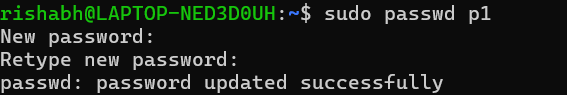
####🔹 Step 3: Create and Assign a Home Directory (if not created)

Some distributions may not create a home directory by default.
To create one manually:
```bash
sudo mkdir /home/username
sudo chown username:username /home/username
```

####🔹 Step 4: Add the User to Groups (Optional)

You can add the new user to specific groups to control permissions:
```bash
sudo usermod -aG groupname username
```

####🔹 Step 5: Use the adduser Command (Simpler Alternative)

Instead of useradd, you can use:
```bash
sudo adduser username
```

####🔹 Step 6: Verify the User

To check whether the user was created successfully:
```bash
id username
```
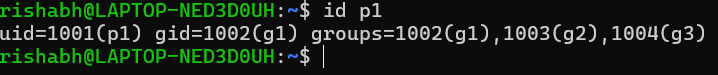

### Q5. What is the grep command and how is it used?

In Linux, the grep command is used to search for specific text patterns in files or command outputs. It stands for Global Regular Expression Print and is very useful for filtering and analyzing text.

####🔹 Step 1: Create a Sample File
echo -e "apple\nbanana\nApple pie\norange\nBanana split" > fruits.txt

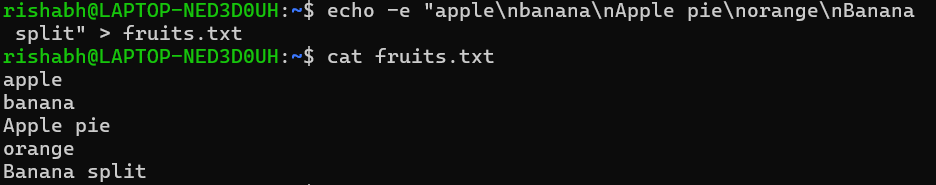
####🔹 Step 2: Basic Search
grep "apple" fruits.txt

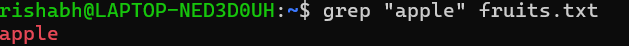
####🔹 Step 3: Case-Insensitive Search
grep -i "apple" fruits.txt

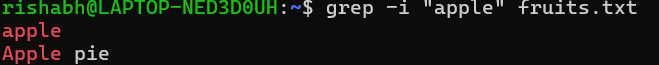
####🔹 Step 4: Show Line Numbers
grep -n "banana" fruits.txt

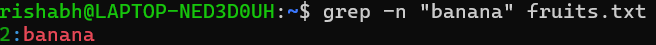
####🔹 Step 5: Count Matches
grep -c "banana" fruits.txt

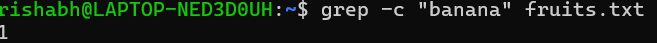
####🔹 Step 6: Search Multiple Patterns (Regex)
grep -E "apple|orange" fruits.txt

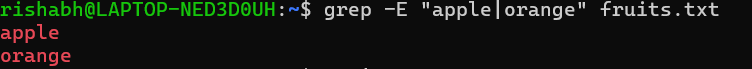
####🔹 Step 7: Search in Command Output
ls | grep ".txt"

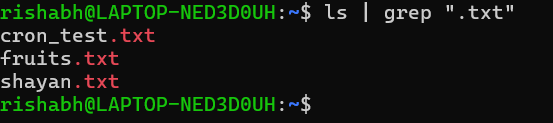

###Q6. Step1: Create user p1
###Step2: He should be part of 3 groups g1,g2,g3.
###Step3: whenever he creates a file automatically in the group section of file grp g1 should come.


#### Step 1: Create groups g1, g2, g3
```bash
sudo groupadd g1
sudo groupadd g2
sudo groupadd g3
```

#### Step 2: Create user p1 with primary group g1
```bash
sudo useradd -m -g g1 -G g2,g3 p1
```

-m → creates home directory /home/p1

-g g1 → sets primary group to g1

-G g2,g3 → adds to secondary groups g2 and g3
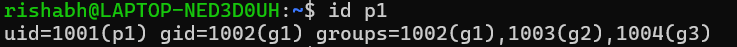
#### Step 3: Set a password for p1
```bash
sudo passwd p1
```
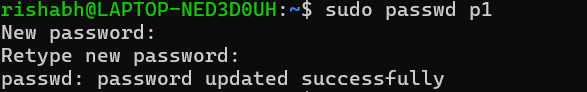
#### Step 4: Ensure files created by p1 belong to g1

By default, a user’s files belong to their primary group, which is g1 here.

To enforce all files in certain directories to inherit group g1, set the setgid bit on that directory:

# Make a directory where all files inherit group g1
```bash
sudo mkdir /shared
sudo chown p1:g1 /shared
sudo chmod 2775 /shared
```

2 in 2775 → setgid bit (makes new files inherit group)

775 → read/write/execute for owner & group

#### ✅ Step 5: Verify
```bash
# Check user groups
id p1

# Check group of a new file in /shared
sudo -u p1 touch /shared/testfile
ls -l /shared/testfile
```
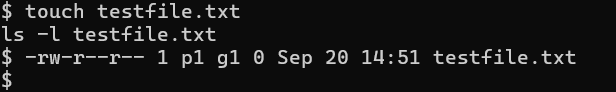

### Q7. Step1: Create directory /tmp/bg as root user and create files inside it.
#### -> Only the root user can create a directory with controlled ownership and permissions initially. Root will set up the directory /tmp/bg and some files inside it before assigning ownership.
```bash
# Create directory
mkdir /tmp/bg

# Create some files inside
touch /tmp/bg/file1 /tmp/bg/file2 /tmp/bg/file3
```
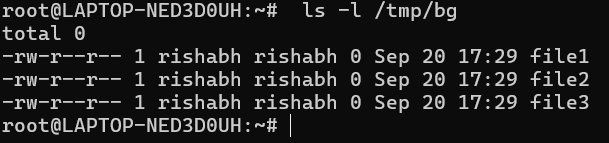

### Step2: “abhi” should be the owner of the directory. He should be able to create files and delete files inside the directory and also he should be able to add content to all files inside the directory.

#### -> Using chown, we make abhi the owner of the directory and files.

#### -> Ownership allows abhi to create and delete files inside the directory.

#### -> Using chmod, we give read and write permission to abhi on files so he can add content.

```bash
# Change ownership of directory and files to abhi
chown -R abhi:abhi /tmp/bg

# Give directory full permissions (abhi can create/delete files)
chmod 755 /tmp/bg

# Give files read & write permission (abhi can edit content)
chmod 644 /tmp/bg/*

```
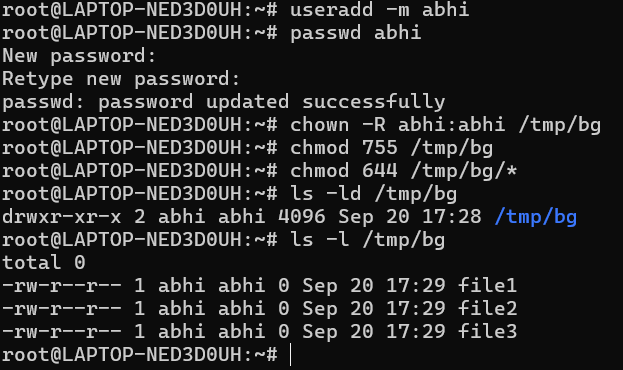

### Q8. You suspect that a particular process is consuming excessive CPU resources on your Linux server. How would you identify and terminate this process?

#### --> On a Linux server, some processes may consume excessive CPU resources, which can slow down the system. To maintain performance, it’s important to identify the culprit process and terminate it if necessary. Linux provides commands like top, ps, and kill to monitor and control processes.

#### -> top: Interactive tool showing CPU, memory, and process information in real-time.

#### -> ps: Provides a snapshot of current processes, which can be sorted by CPU usage.

#### -> kill / pkill: Terminates a process using its PID or name.

#### Step 1: Identify the process consuming high CPU

#### -> Using top:
```bash
top
```
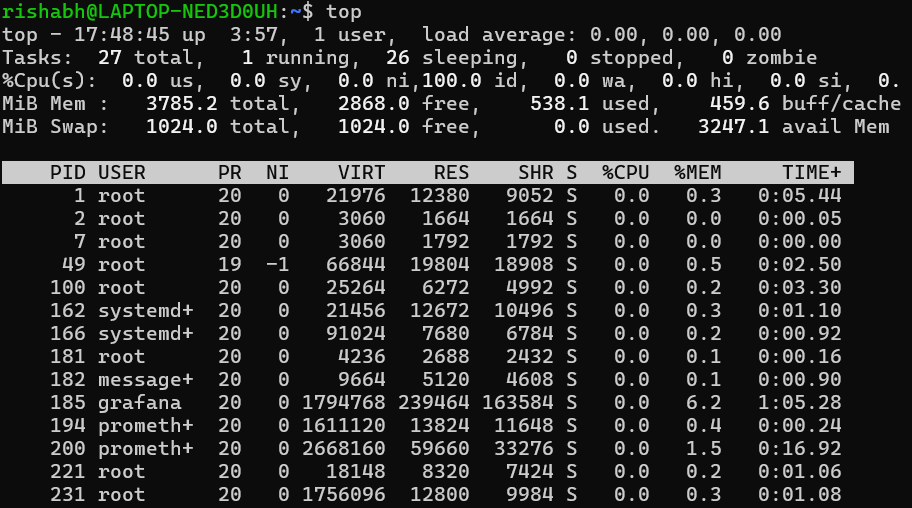
#### Step 2: Terminate the process

#### -> Graceful termination:
```bash
kill <PID>
```
#### -> Force termination (if it doesn’t stop):
```bash
kill -9 <PID>
```

#### -> Terminate by process id:
```bash
kill process_id
```
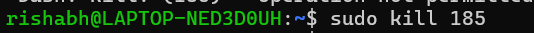

Step 3: Verify termination
```bash
top          # Check if CPU usage has dropped
ps -p <PID>  # Ensure the process is no longer running
```
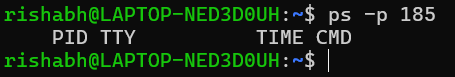